## AugurPy cell type priorization

In [1]:
import scanpy as sc
import pertpy as pt
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!

Running Scanpy 1.9.1, on 2024-09-28 13:34.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad'

In [3]:
## plotting variables
fig_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'
results_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/pertpy_results/'
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispe

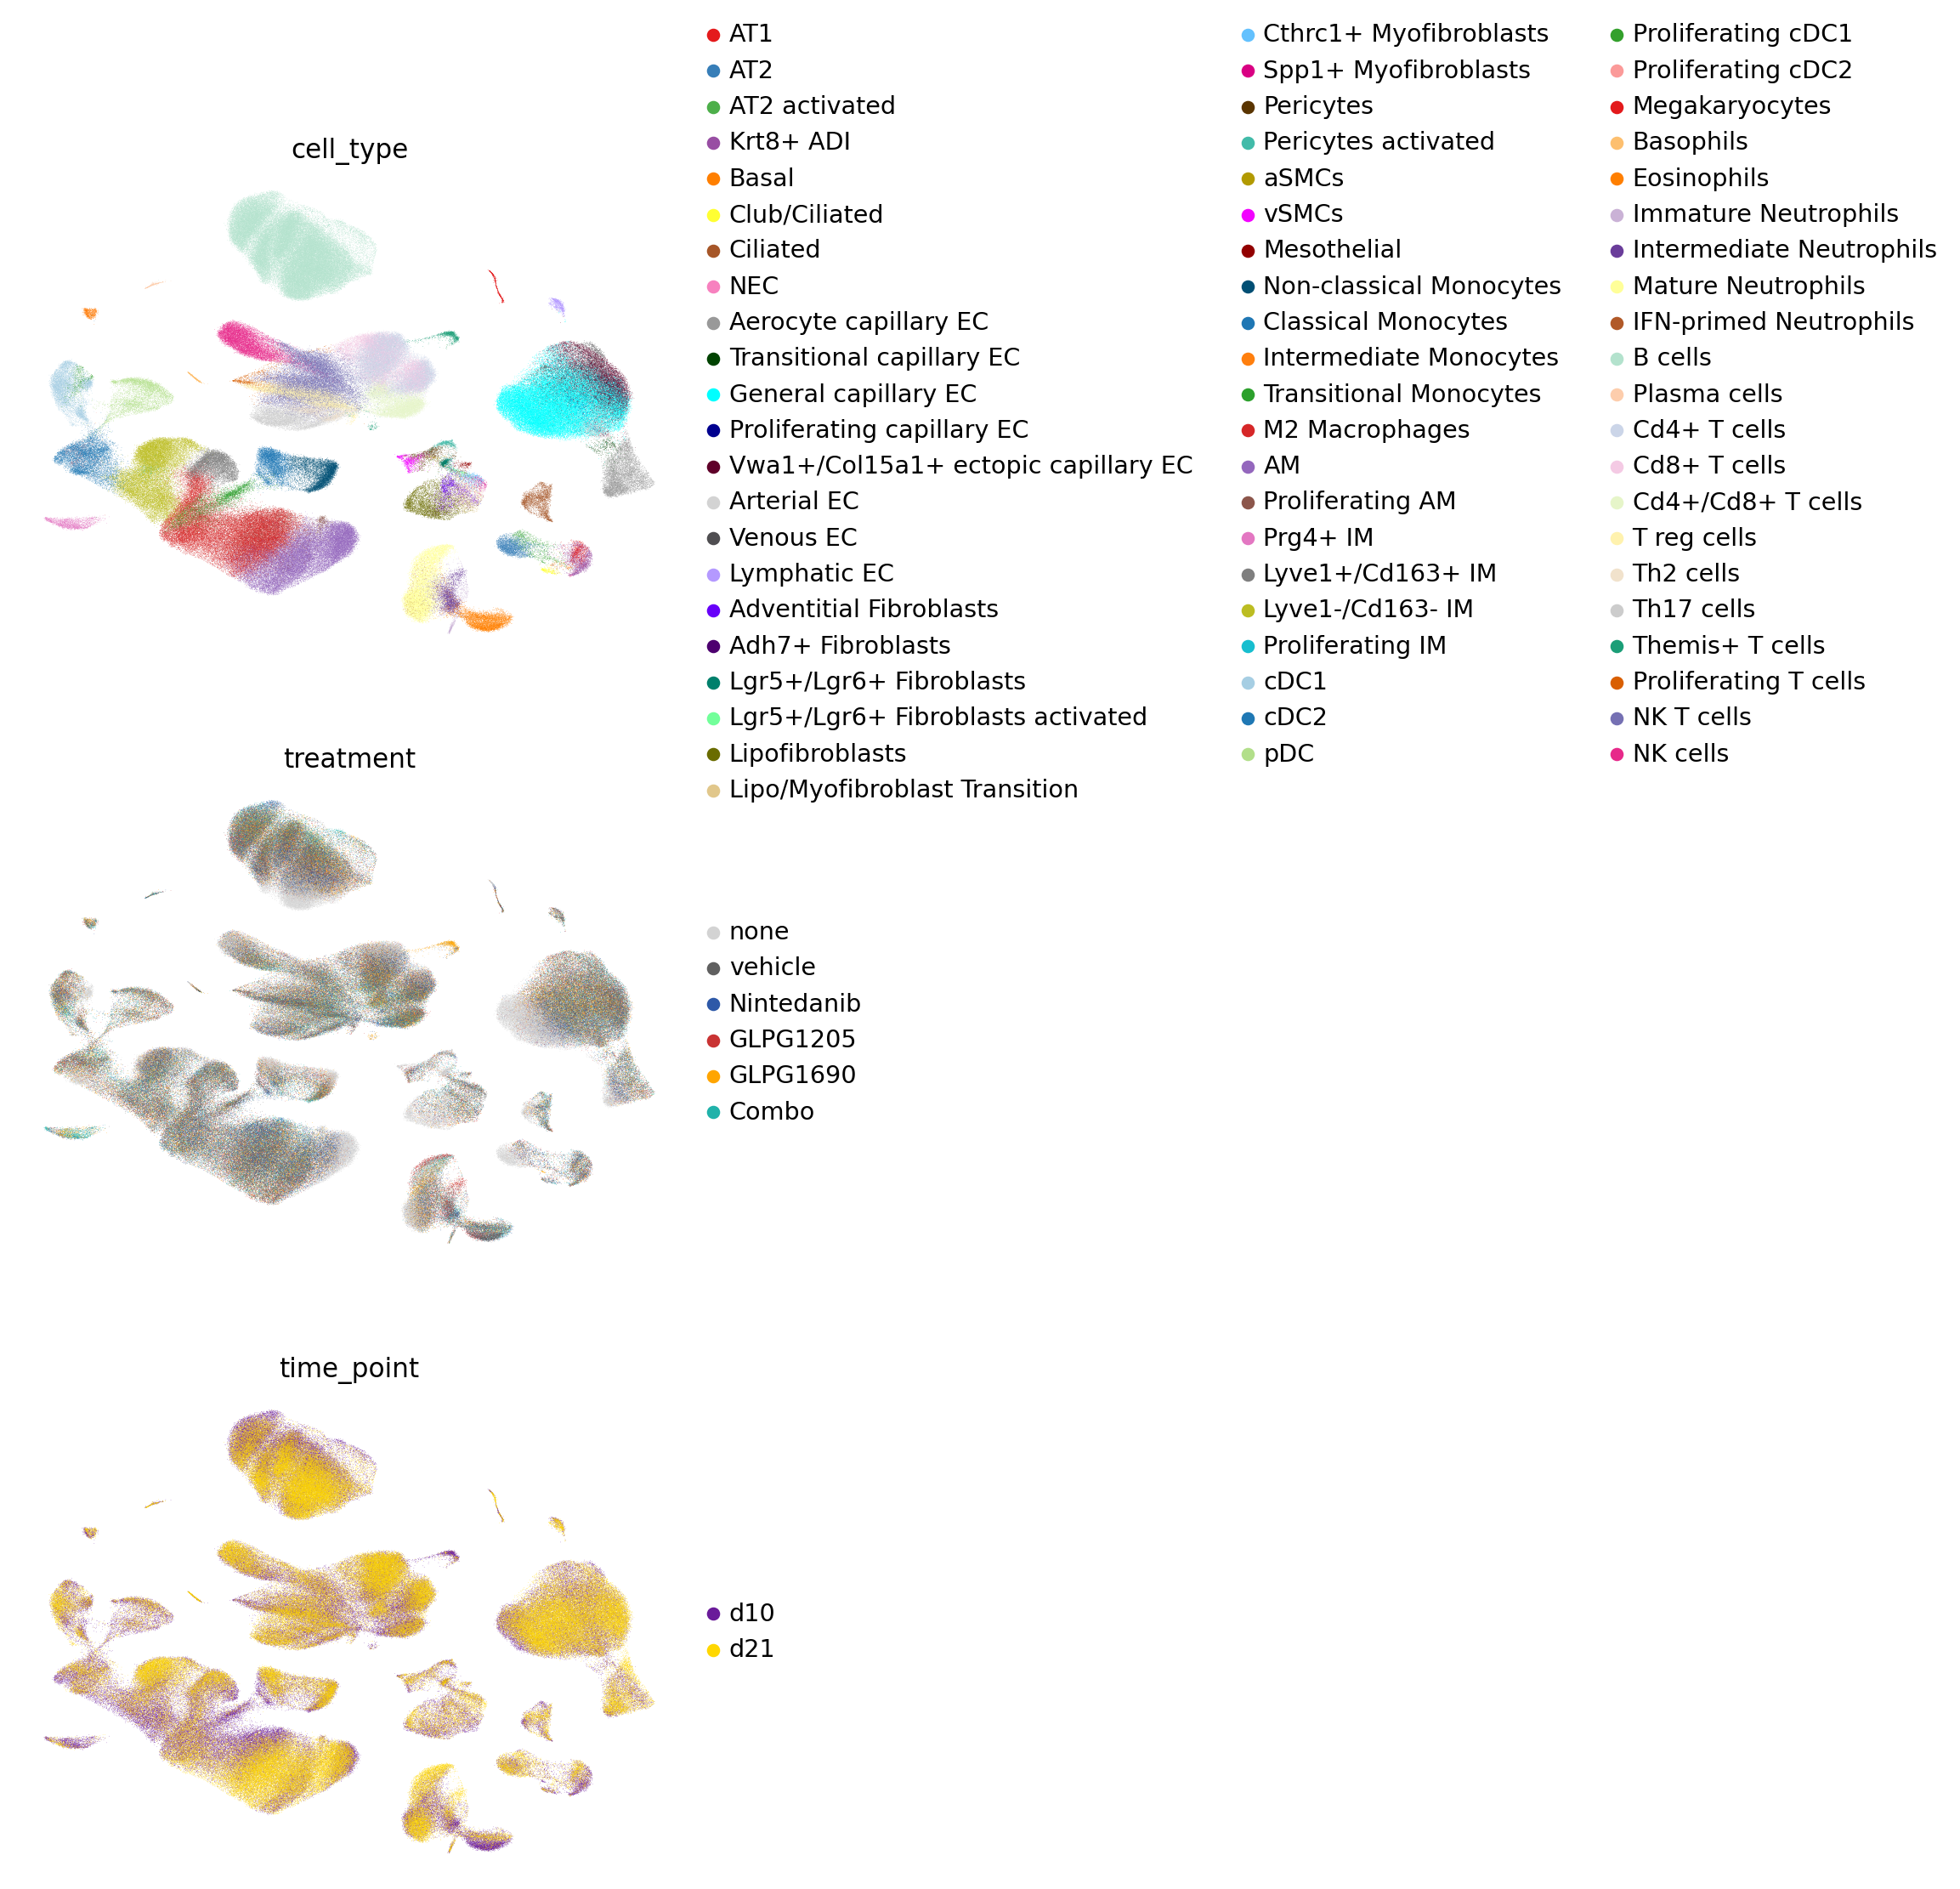

In [6]:
## overview UMAPs
sc.pl.umap(adata, color = ['cell_type','treatment','time_point'], ncols = 1, frameon = False)

In [7]:
pd.crosstab(adata.obs['treatment'],adata.obs['cell_type'])

cell_type,AT1,AT2,AT2 activated,Krt8+ ADI,Basal,Club/Ciliated,Ciliated,NEC,Aerocyte capillary EC,Transitional capillary EC,...,Cd4+ T cells,Cd8+ T cells,Cd4+/Cd8+ T cells,T reg cells,Th2 cells,Th17 cells,Themis+ T cells,Proliferating T cells,NK T cells,NK cells
treatment,,,,,,,,,,,,,,,,,,,,,
none,25,2613,57,7,0,69,846,5,1819,66,...,3823,2852,68,82,639,1180,137,91,1738,3021
vehicle,181,15,158,372,27,38,292,2,850,66,...,2671,1599,1823,1390,323,985,23,214,2489,1138
Nintedanib,172,83,393,452,24,82,521,10,1457,75,...,3632,2802,1755,1610,536,1759,60,205,3820,1795
GLPG1205,186,89,266,449,20,54,311,8,1049,87,...,3485,2371,1731,1372,381,1137,22,247,2730,1553
GLPG1690,140,62,208,320,17,27,446,13,1027,90,...,4327,2606,2173,1597,484,1338,898,262,3760,1919
Combo,200,4,192,440,17,67,512,6,1099,101,...,3809,2279,2392,2333,544,1569,34,194,4007,1707


In [8]:
## random forest classifier for categorical 'treatment' variable
ag_rfc = pt.tl.Augurpy('random_forest_classifier')

In [9]:
adata.obs.treatment.value_counts()

Combo         79883
Nintedanib    78405
GLPG1690      78356
none          76155
GLPG1205      70156
vehicle       59484
Name: treatment, dtype: int64

In [10]:
## list of treatments
treatments = ['Nintedanib','GLPG1205','GLPG1690','Combo']

In [11]:
## presets for plotting
plt.rcParams['figure.figsize'] = (8, 15)

In [12]:
## subset to day 21 only
adata = adata[adata.obs.time_point.isin(['d21'])].copy()

Set smaller span value in the case of a `segmentation fault` error.

Set larger span in case of svddc or other near singularities error.

Output()

Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is 0.9.4!
Installed version 0.2.0 of pertpy is outdated. Newest version is

Skipping Club/Ciliated cell type - 42 samples is less than min_cells 100.

...

Skipping Plasma cells cell type - 79 samples is less than min_cells 100.

Skipping Themis+ T cells cell type - 28 samples is less than min_cells 100.

Skipping Basophils cell type - 93 samples is less than min_cells 100.

Skipping IFN-primed Neutrophils cell type - 33 samples is less than min_cells 100.

Skipping Megakaryocytes cell type - 68 samples is less than min_cells 100.

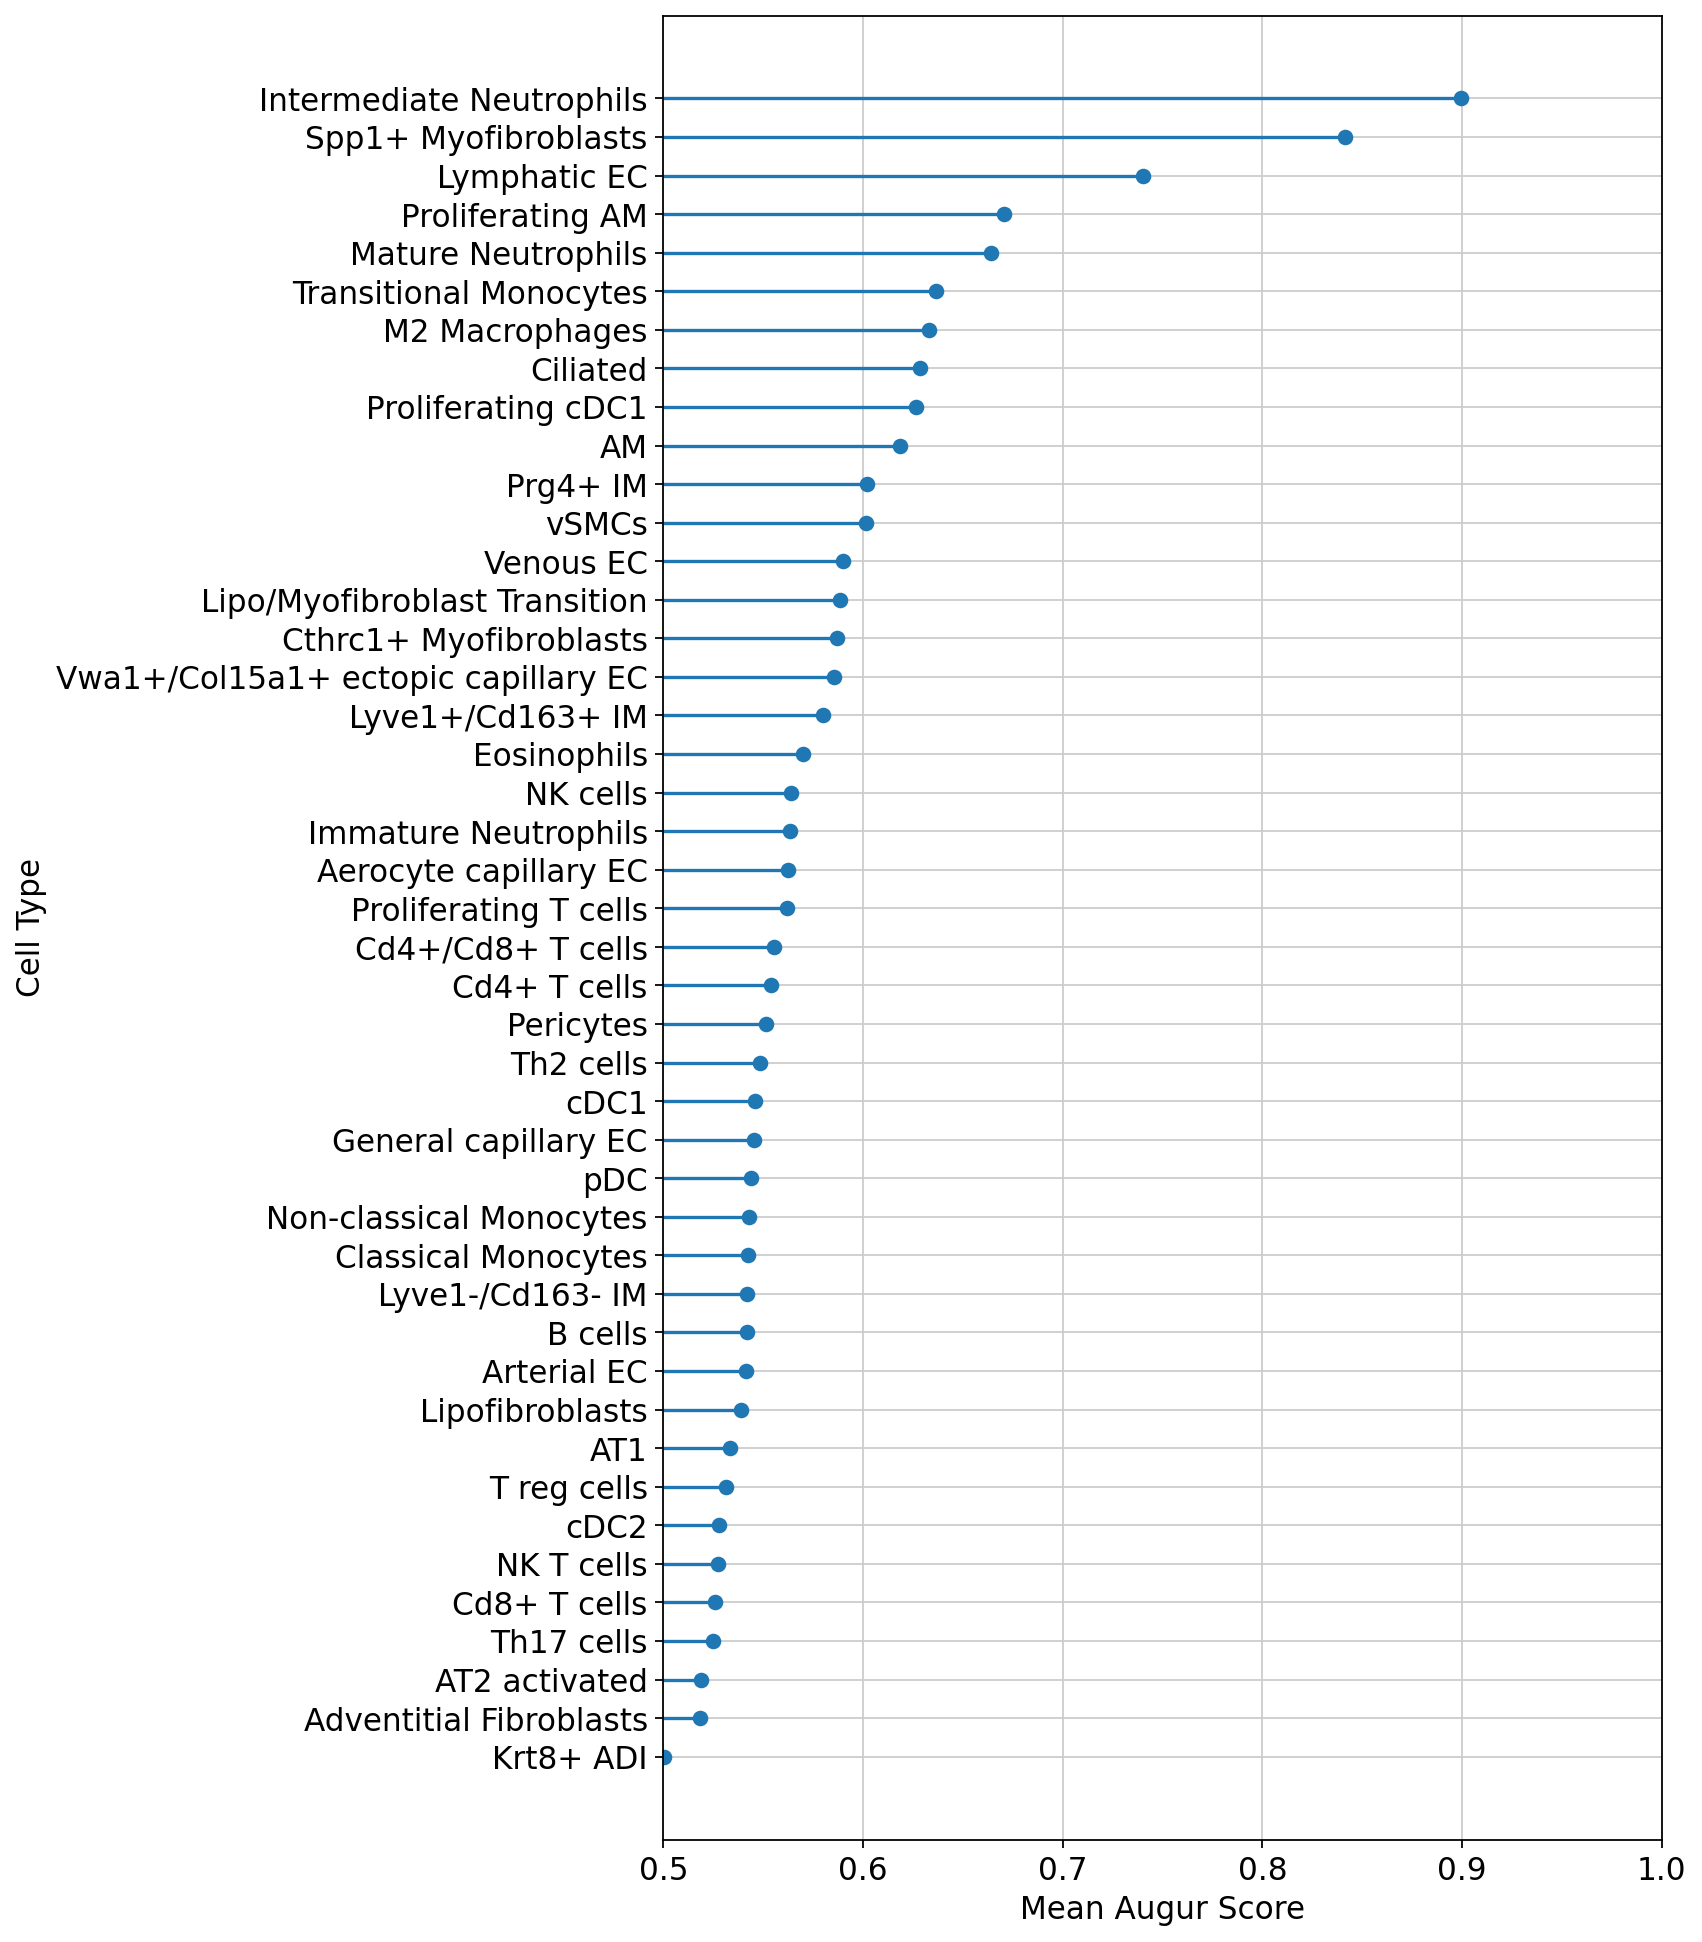

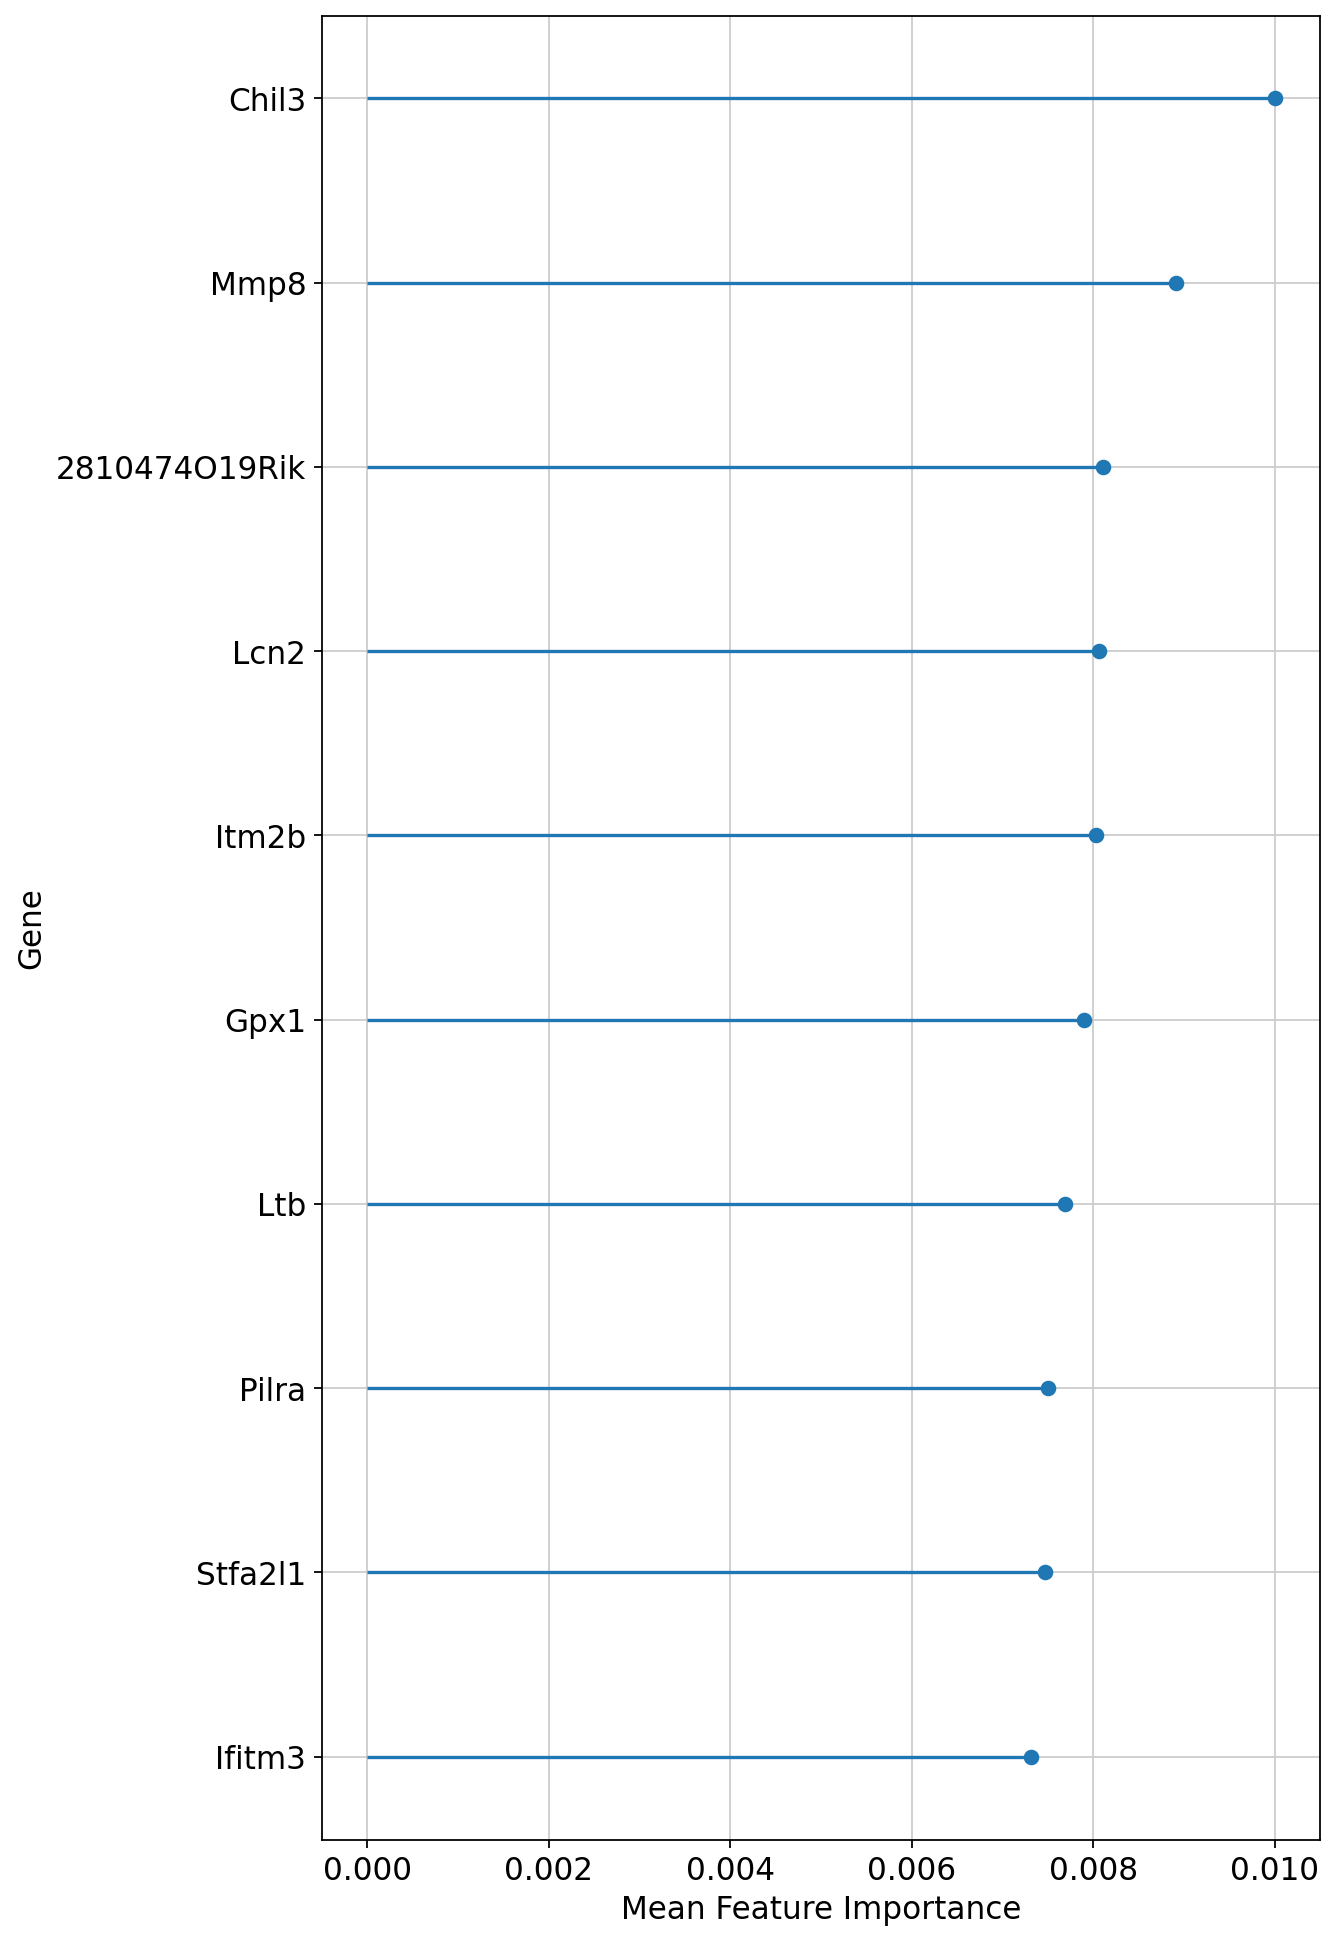

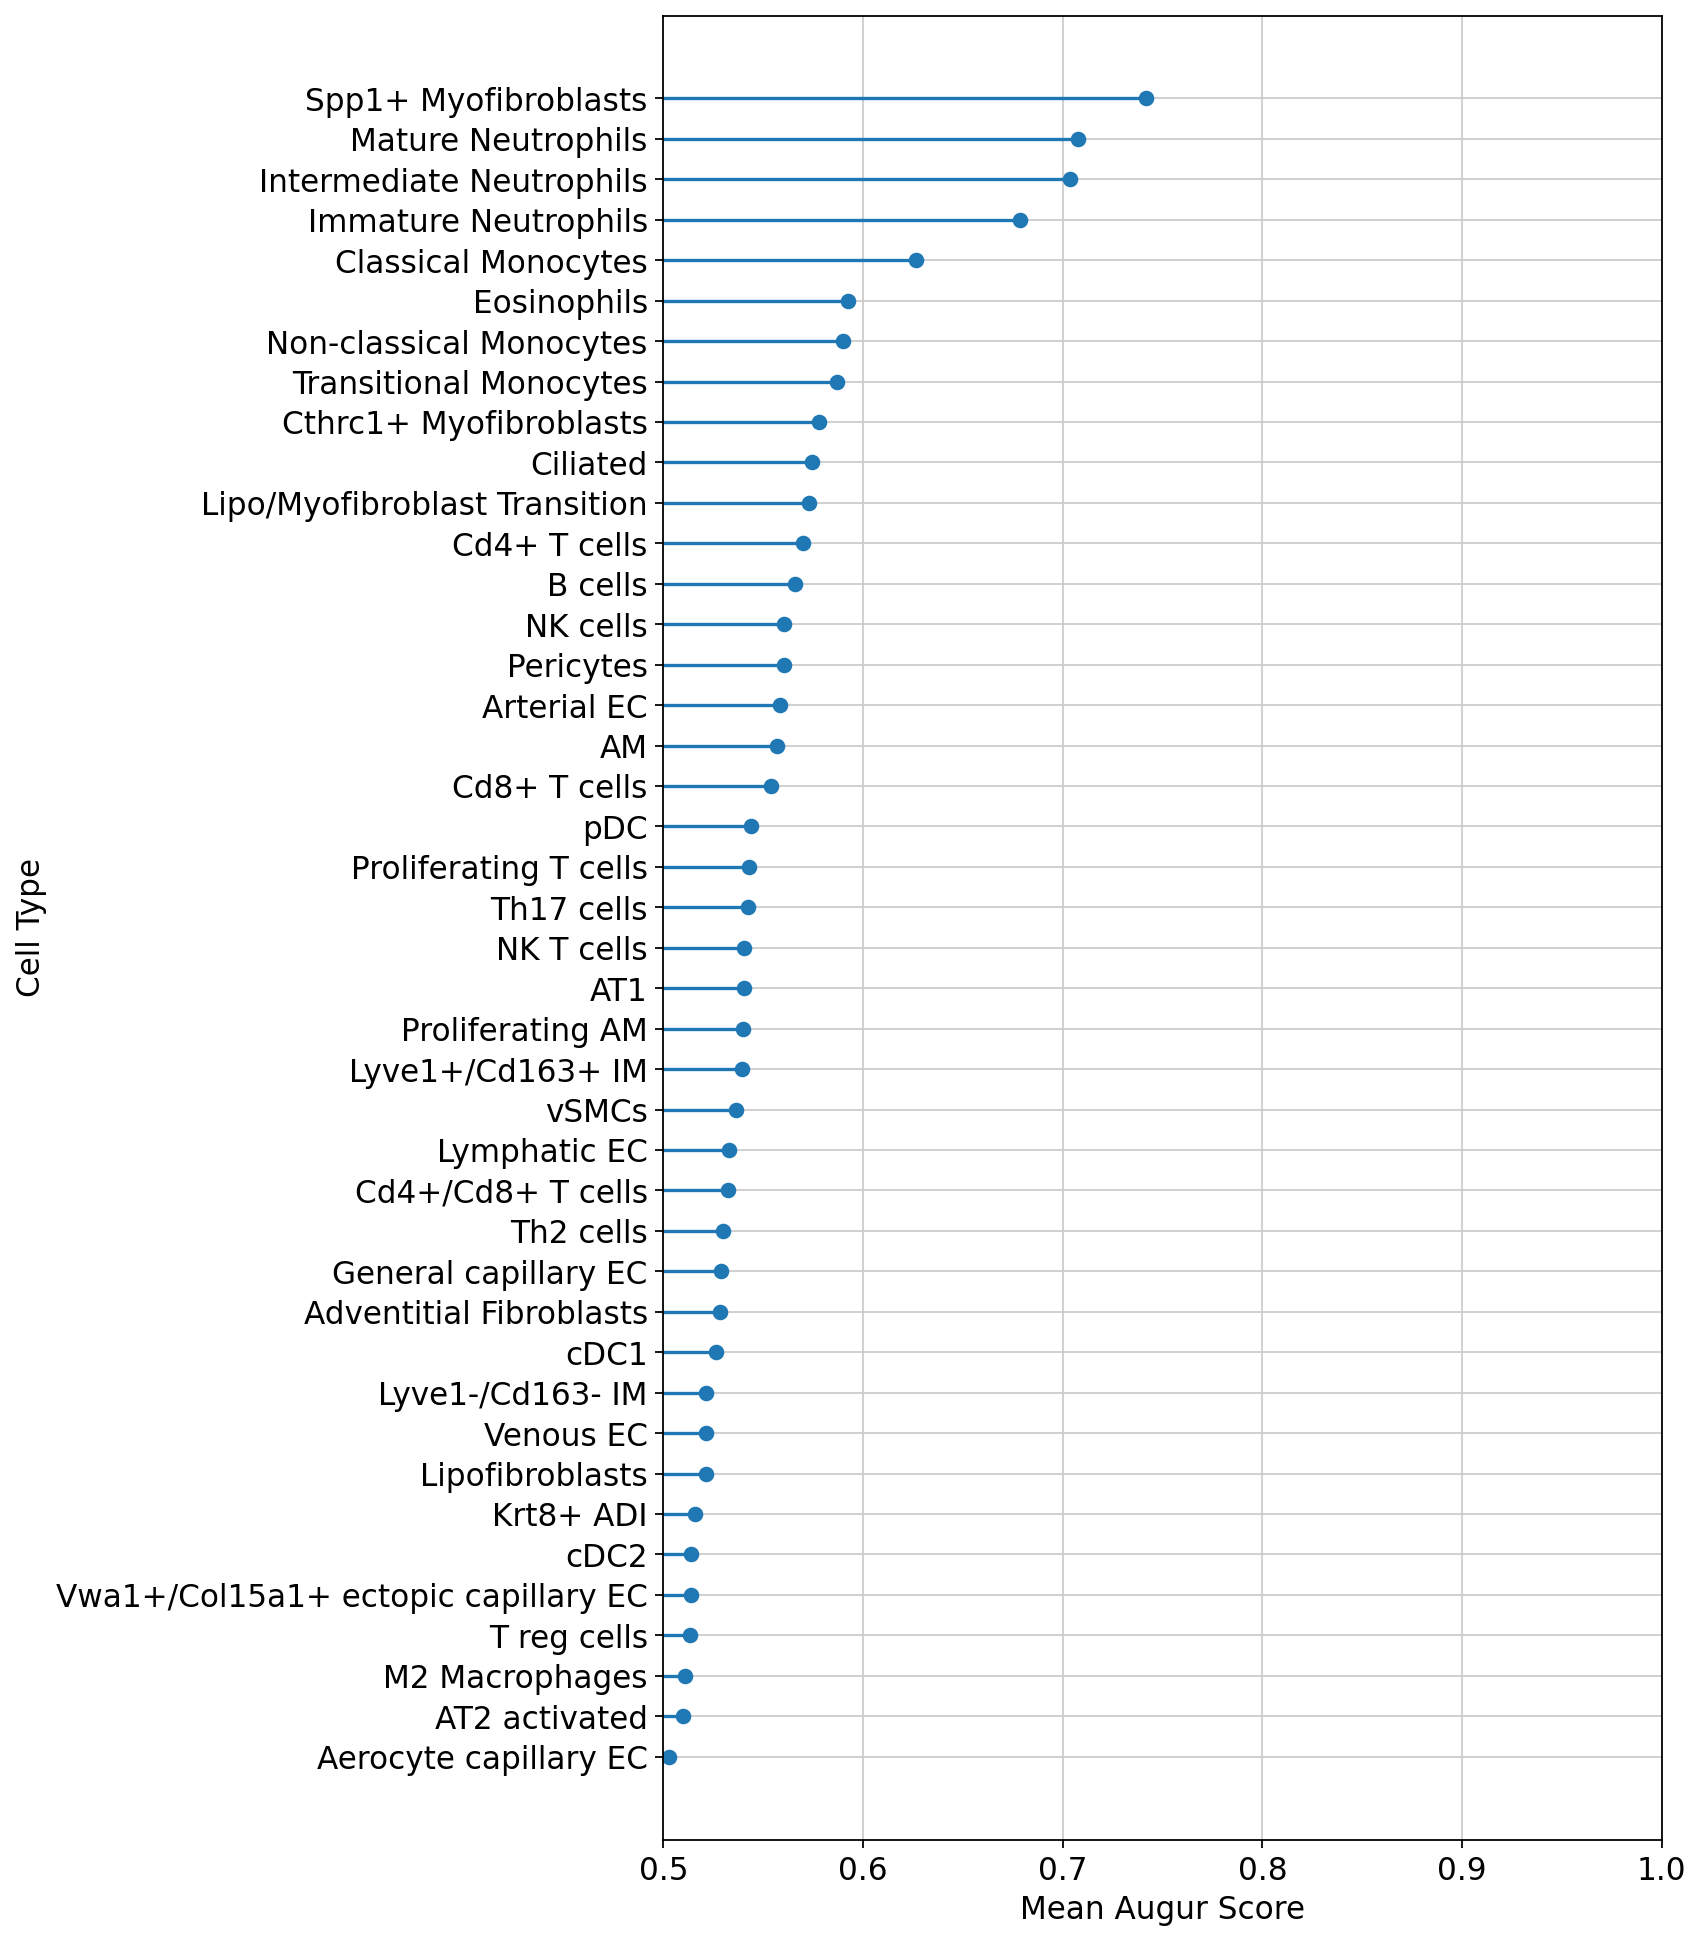

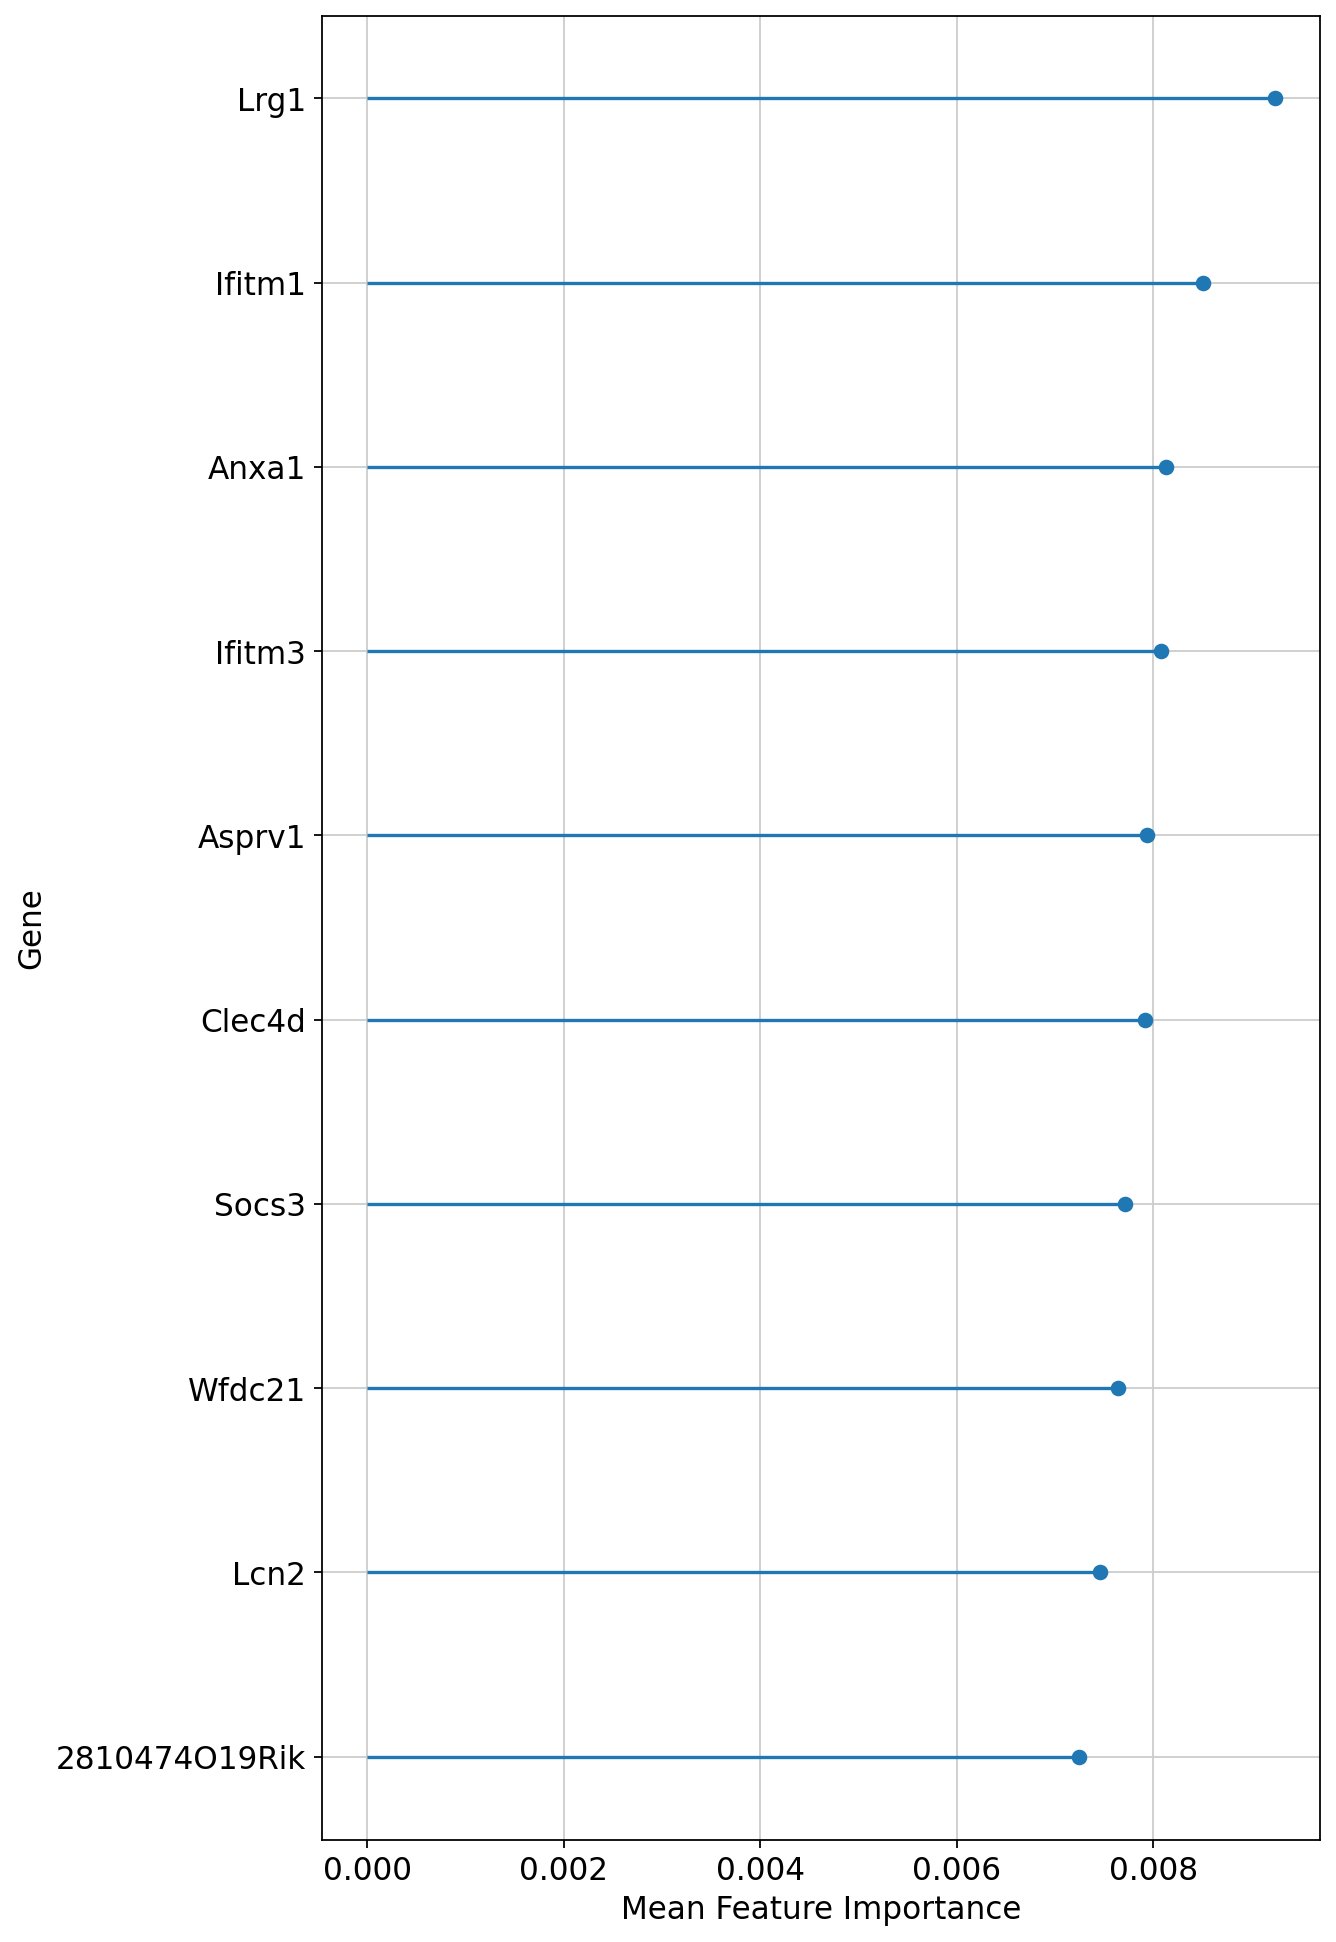

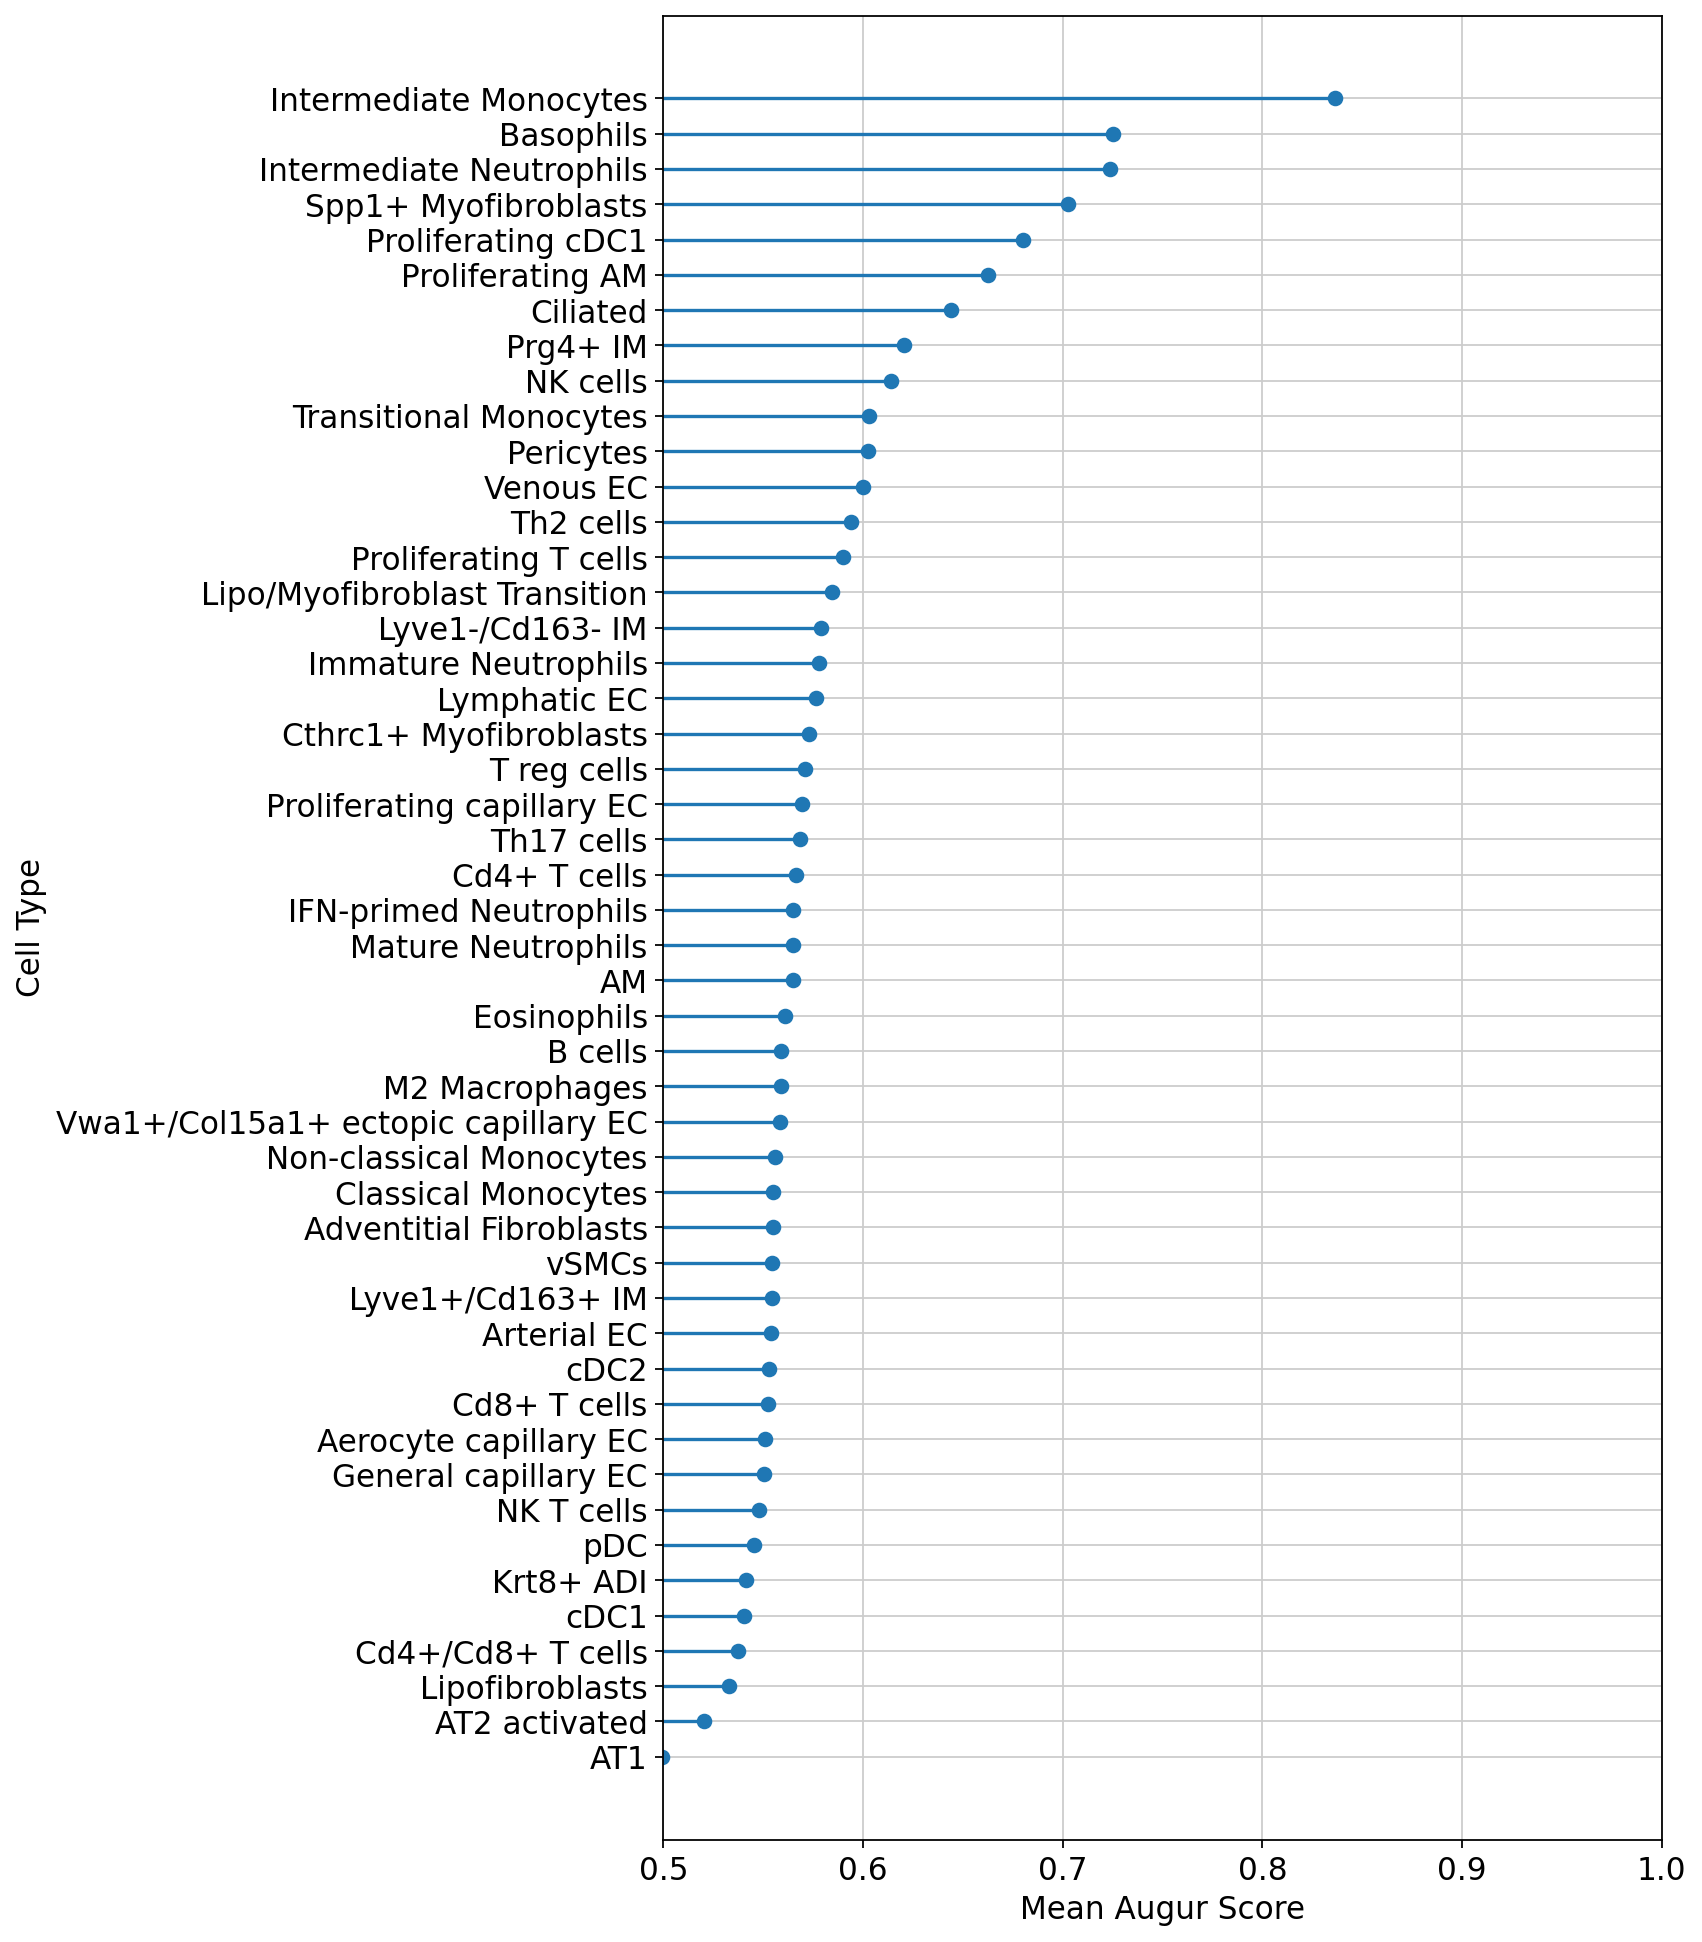

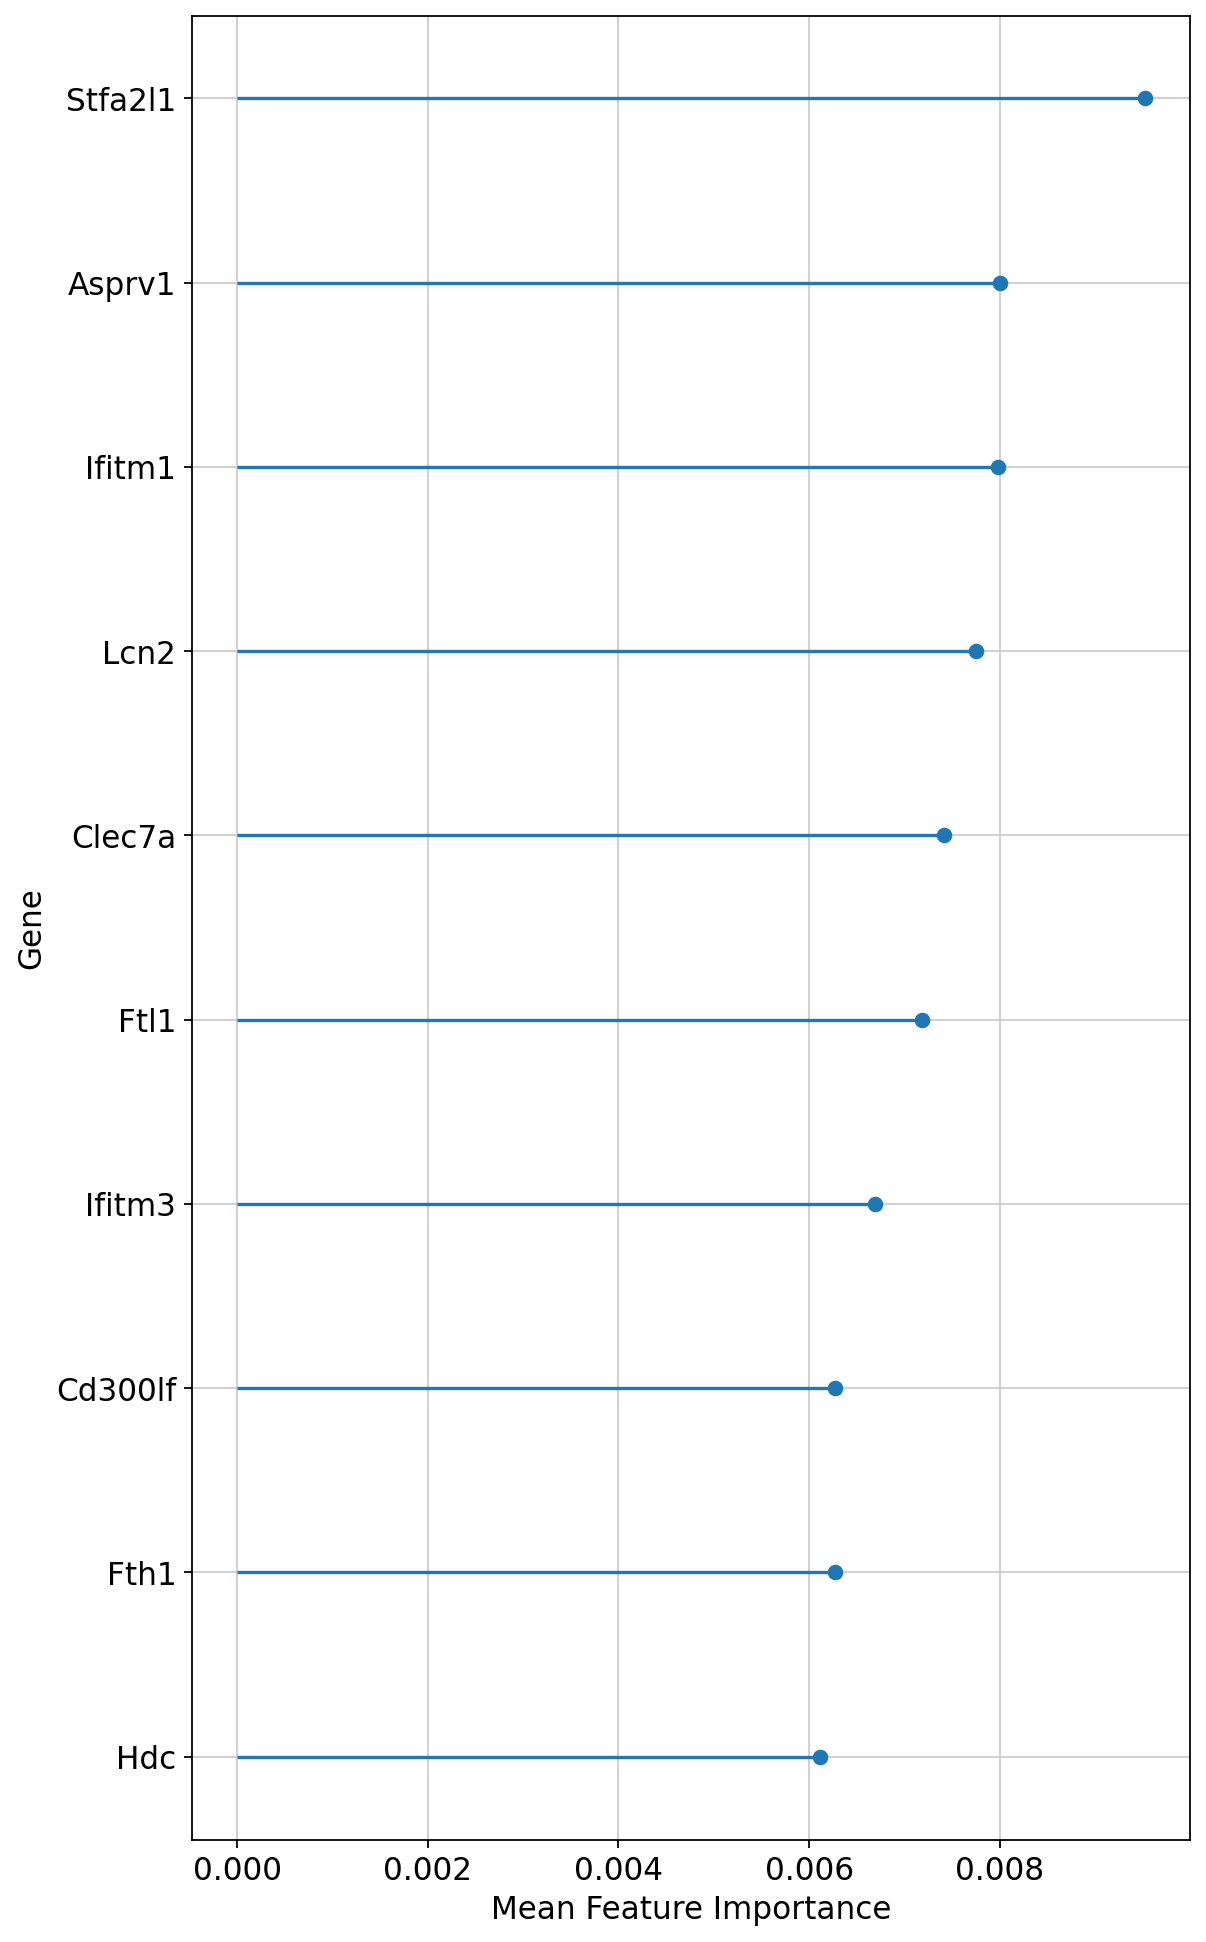

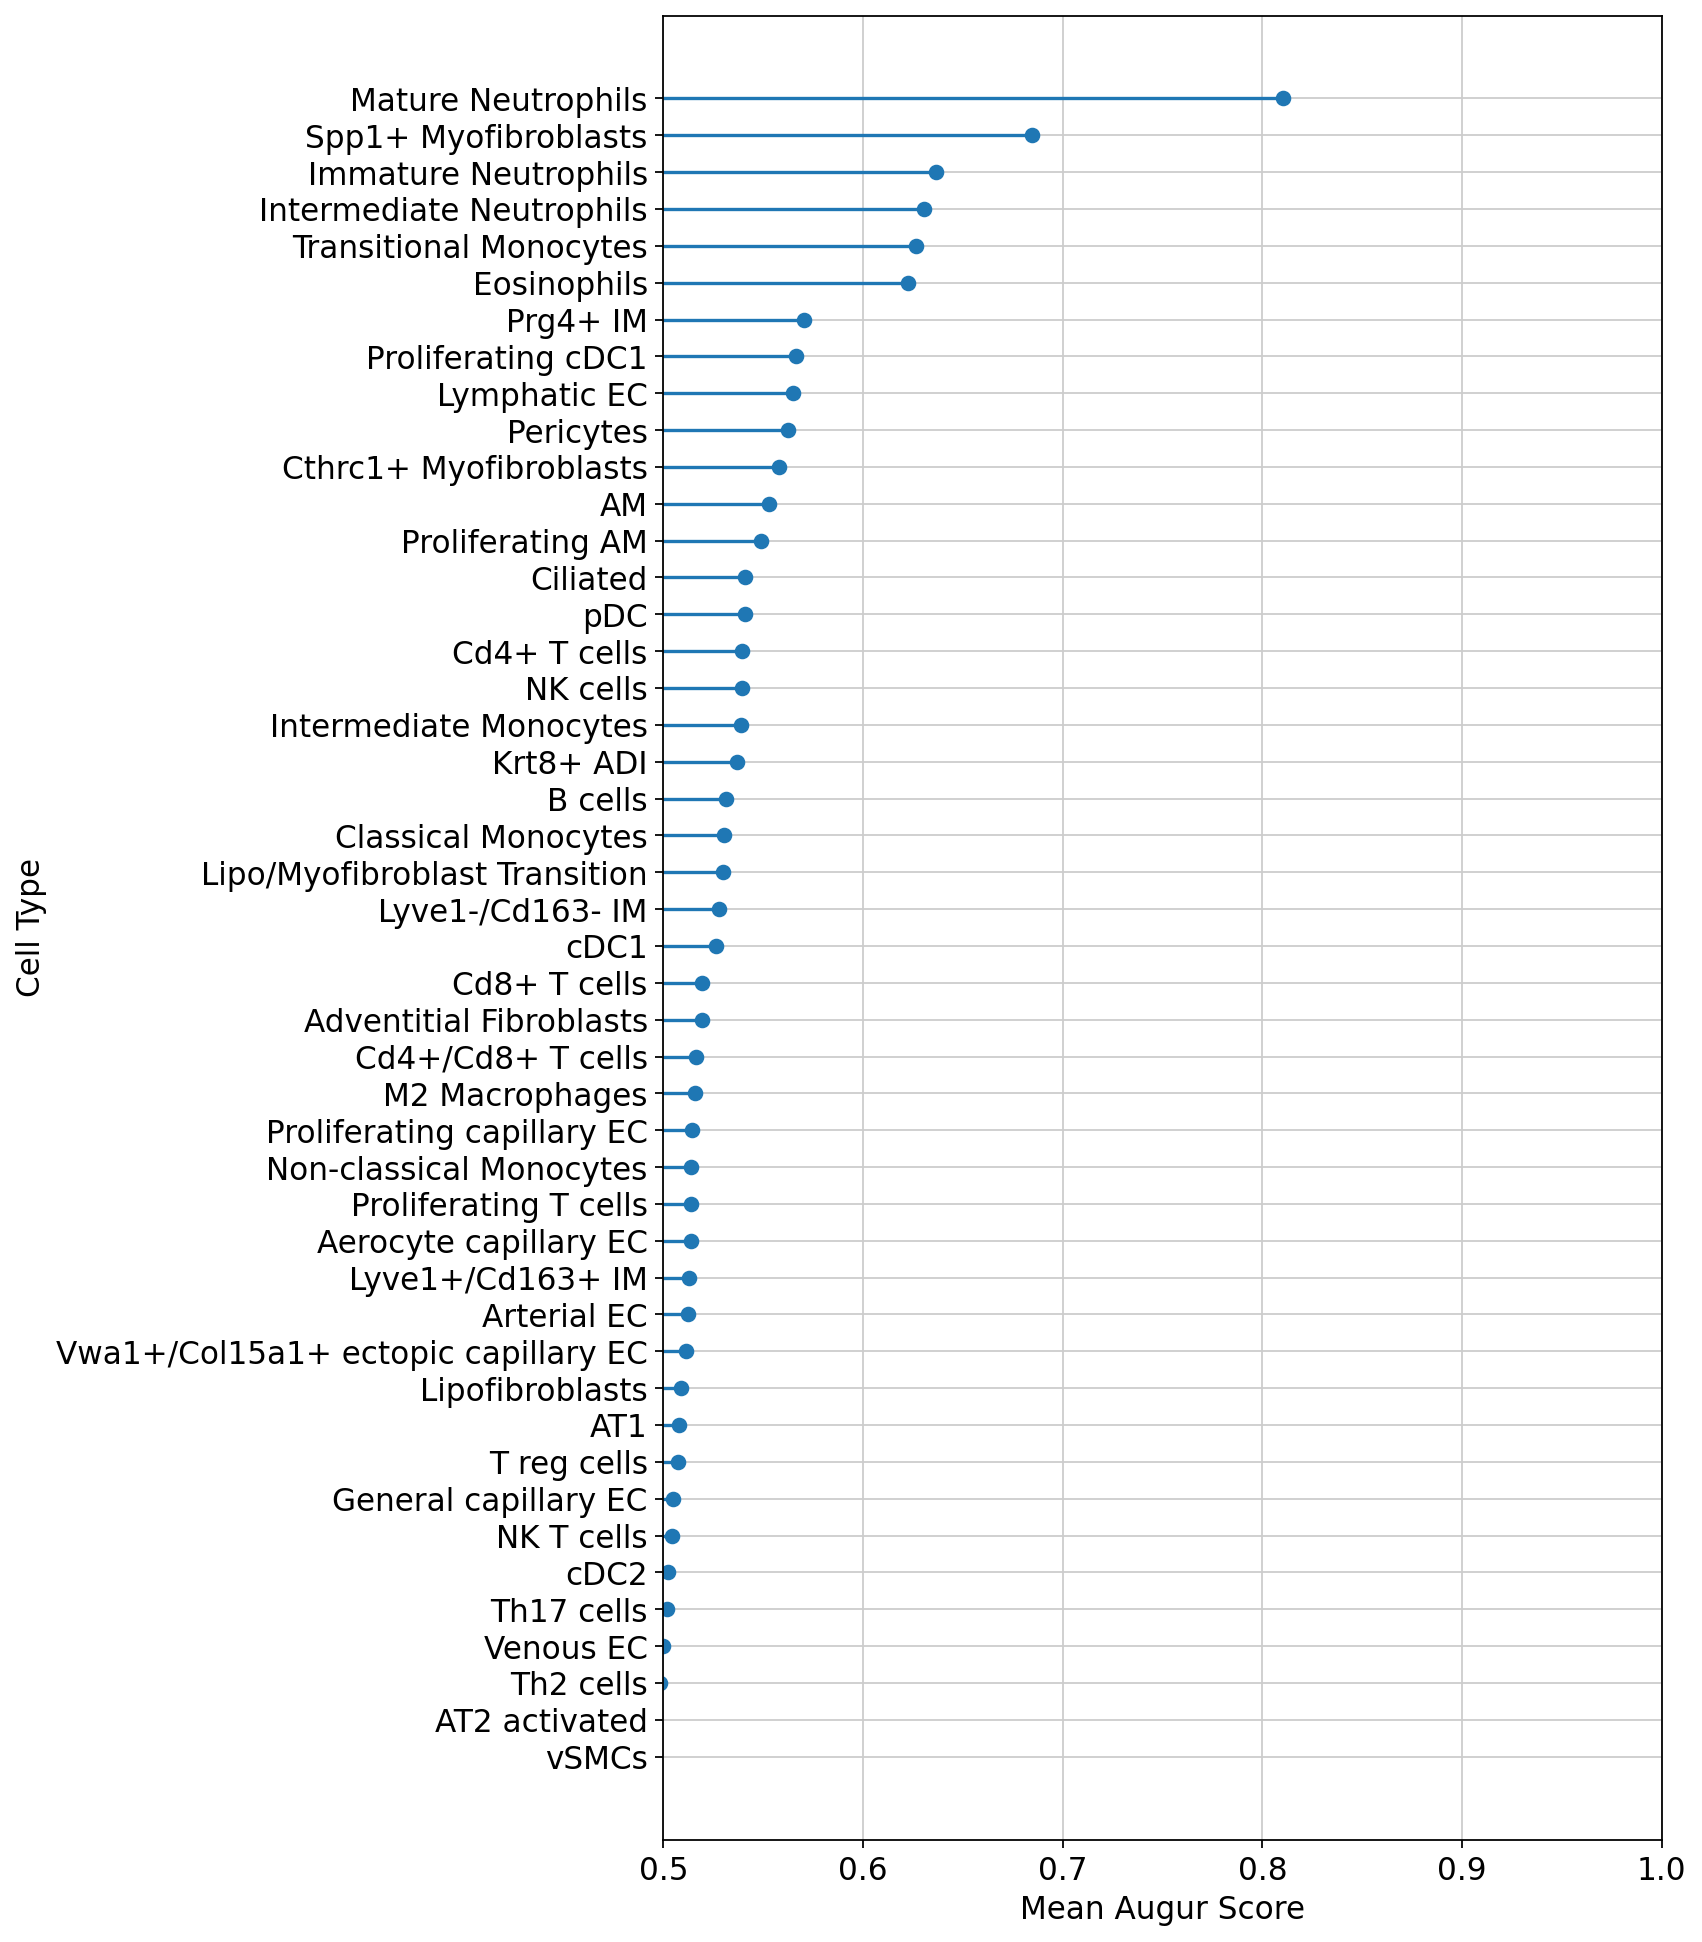

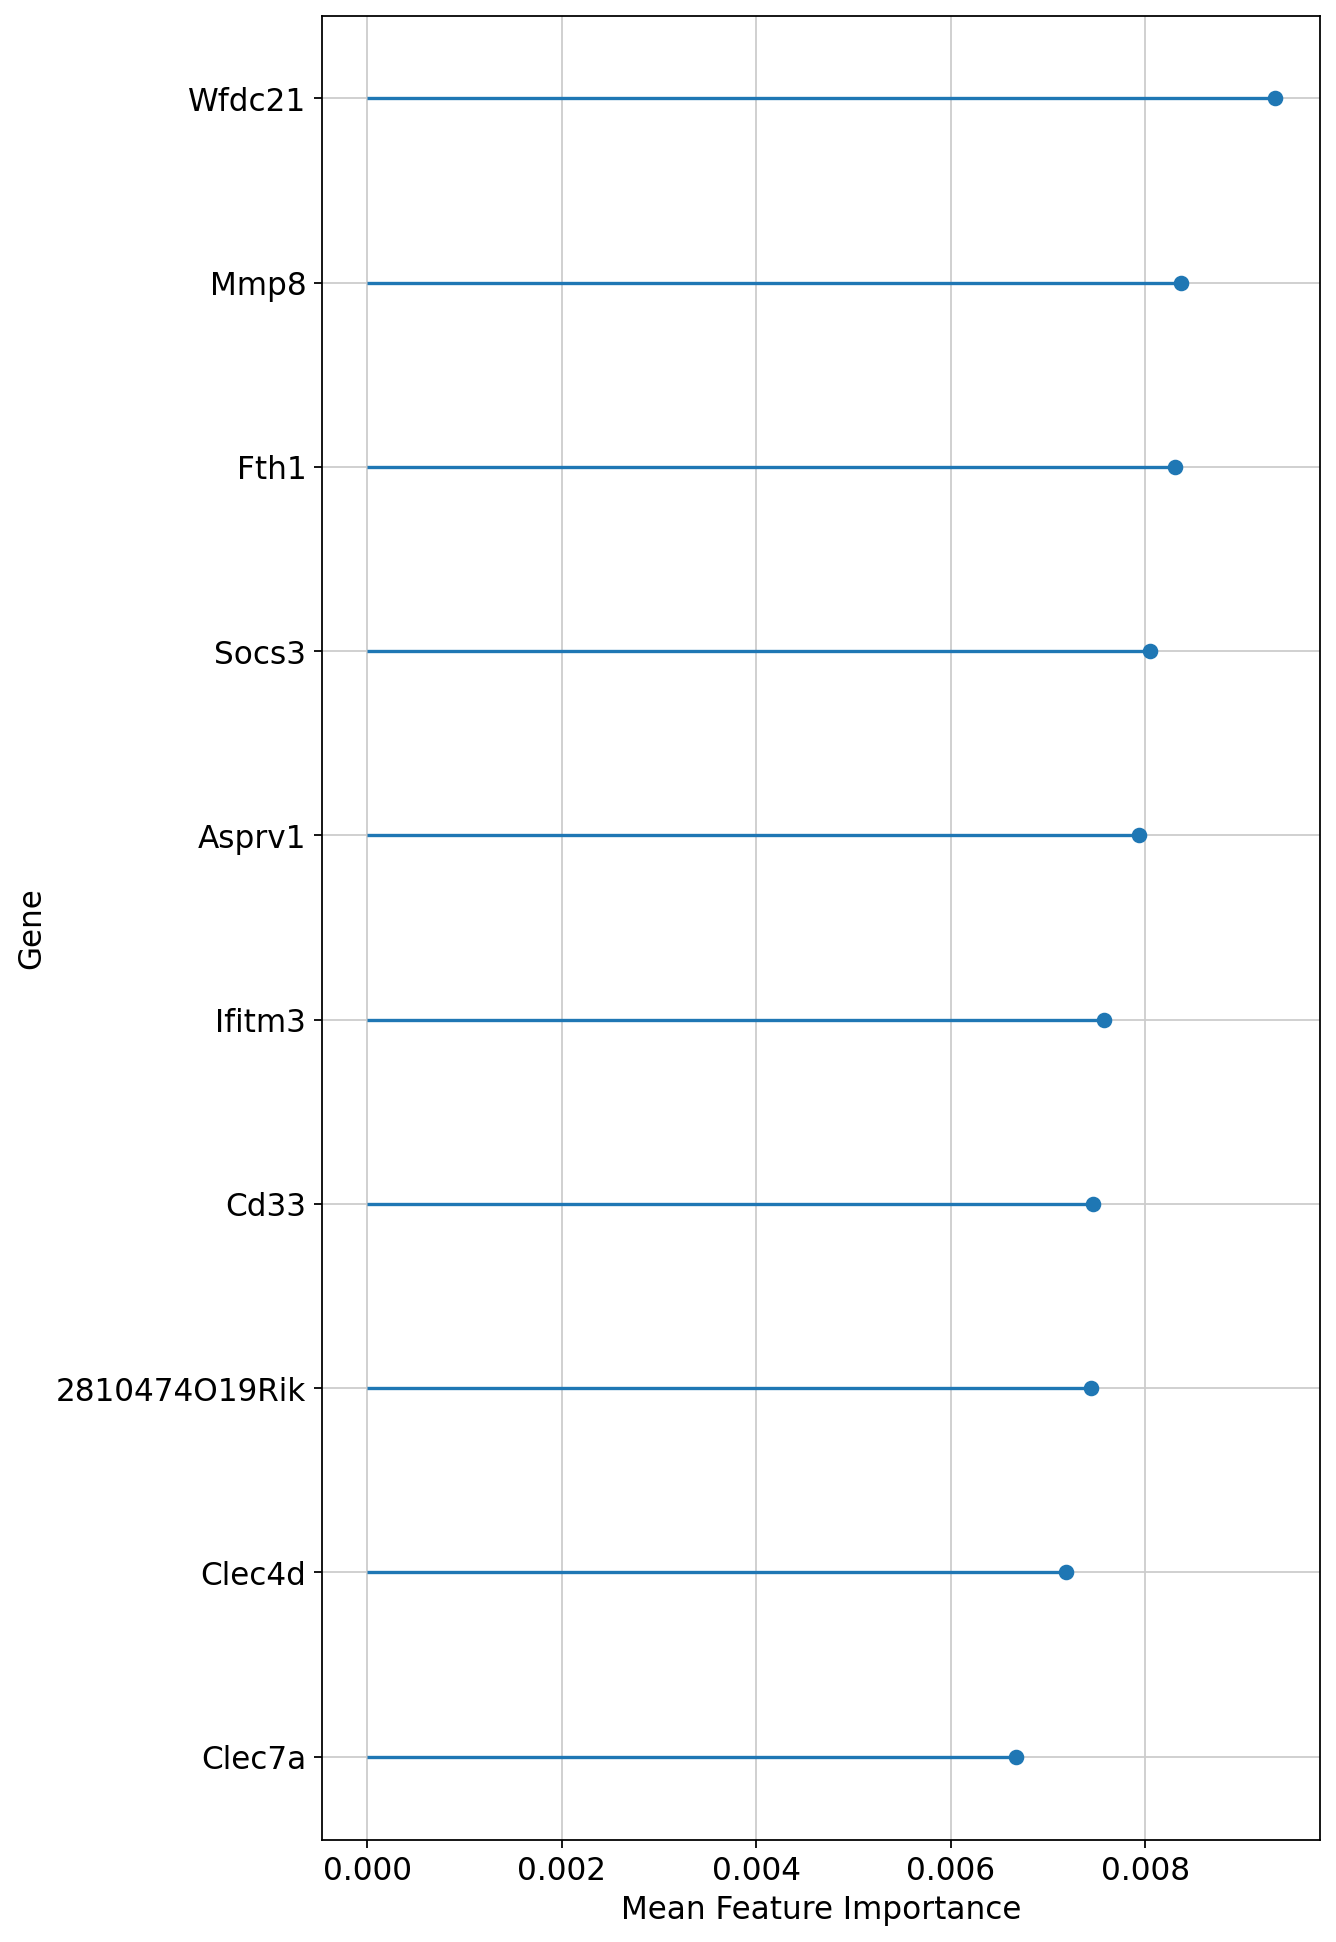

In [14]:
for t in treatments:
    
    ## subset adata
    subset = adata[adata.obs.treatment.isin(['vehicle',t])].copy()
    
    ## rename adata.obs columsn
    subset.obs['label'] = subset.obs['treatment']
    
    ## load data
    loaded_data = ag_rfc.load(subset)
    loaded_data.var['name'] = loaded_data.var_names
    
    ## run augurpy
    subset, results = ag_rfc.predict(loaded_data, 
                                     n_subsamples=100,
                                     subsample_size=10,
                                     n_threads=32,
                                     select_variance_features=True)
    
    ## print prelim results to screen
    results['summary_metrics'].head(2)
    
    ## plot lollipop plot
    pt.pl.ag.lollipop(results)
    plt.xlim([0.5, 1.0])
    plt.savefig(fig_dir + f'pertpy_lollipop_{t}.pdf')
    
    ## plot top 10 genes
    pt.pl.ag.important_features(results, top_n=10)
    plt.savefig(fig_dir + f'pertpy_top10_genes_{t}.pdf')
    
    ## create results data frame
    df = results['summary_metrics'].loc['mean_augur_score',]
    df = pd.DataFrame(df)
    df['treatment'] = t
    df.reset_index(inplace=True)
    df.rename(columns = {'index':'cell_type'}, inplace = True)
    
    ## save results df
    df.to_csv(results_dir + f'augur_scores_{t}.csv', sep=',') 